In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from scipy.stats import uniform, randint
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

In [2]:
data_train = pd.read_csv('C:/Users/user/ML/project1/data/data_train.csv')
X_train = data_train.drop('Heart Disease Status', axis=1)
y_train = data_train['Heart Disease Status']

In [3]:
data_test = pd.read_csv('C:/Users/user/ML/project1/data/data_test.csv')
X_test = data_test.drop('Heart Disease Status', axis=1)
y_test = data_test['Heart Disease Status']

In [4]:
y_train.value_counts()

Heart Disease Status
0    6000
1    1500
Name: count, dtype: int64

In [5]:
y_test.value_counts()

Heart Disease Status
0    2000
1     500
Name: count, dtype: int64

- для учета дисбаланса классов использовались веса классов class_weights. Другие методы, такие как resample и SMOTE, были опробованы, но не применялись в финальных моделях. 
- порог классификации и параметр весов был выбран один для всех моделей. Подбор порога выполнялся интуитивно для упрощения экспериментов и единообразного сравнения моделей.
- для обучения выбраны три модели: Logistic Regression, Random Forest, XGBoost
- упор на метрики precision, f1-score,  recall (так как важно чтобы был правильно определен положительный класс)

In [6]:
skf = StratifiedKFold(shuffle=True, n_splits=5, random_state=42)

In [7]:
class_weights = {0: 1, 1: 4}
threshold = 0.485

Logistic Regression

              precision    recall  f1-score   support

           0       0.80      0.34      0.47      2000
           1       0.20      0.67      0.31       500

    accuracy                           0.40      2500
   macro avg       0.50      0.50      0.39      2500
weighted avg       0.68      0.40      0.44      2500



<Axes: >

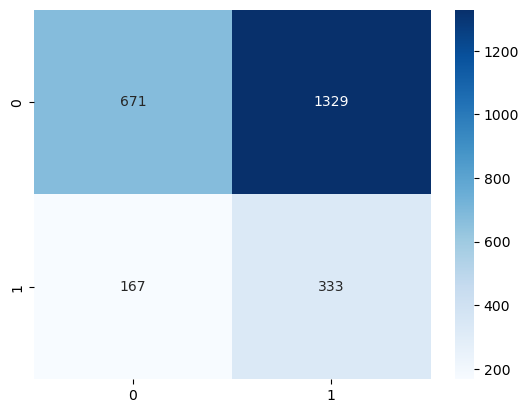

In [8]:
log_reg = LogisticRegression(class_weight=class_weights, random_state=42)
log_reg.fit(X_train, y_train)
y_proba = log_reg.predict_proba(X_test)[:, 1]

y_pred_log = (y_proba > threshold).astype(int)

print(classification_report(y_test, y_pred_log))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')

In [9]:
print(f'recall {recall_score(y_test, y_pred_log)}')
print(f'precision {precision_score(y_test, y_pred_log)}')
print(f'f1 {f1_score(y_test, y_pred_log)}')

recall 0.666
precision 0.2003610108303249
f1 0.3080481036077706


In [10]:
param_grid = {
    'C': [0.001, 0.01, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

gs_logreg = GridSearchCV(estimator=LogisticRegression(class_weight=class_weights, random_state=42), 
                         param_grid=param_grid, cv=skf,
                         scoring='recall')

gs_logreg.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

              precision    recall  f1-score   support

           0       0.81      0.21      0.34      2000
           1       0.20      0.80      0.32       500

    accuracy                           0.33      2500
   macro avg       0.50      0.50      0.33      2500
weighted avg       0.69      0.33      0.33      2500



<Axes: >

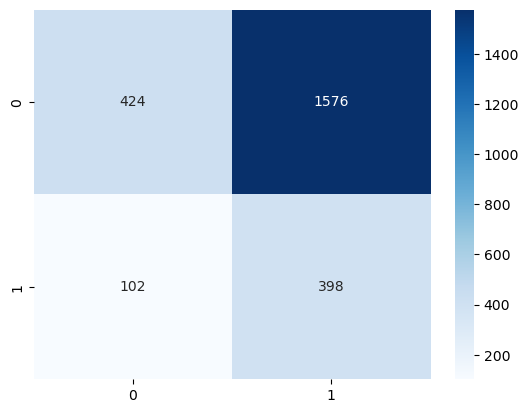

In [11]:
y_proba_grid= gs_logreg.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_grid_log = (y_proba_grid > threshold).astype(int)
print(classification_report(y_test, y_pred_grid_log))
sns.heatmap(confusion_matrix(y_test, y_pred_grid_log), annot=True, fmt='d', cmap='Blues')

In [12]:
print(f'recall {recall_score(y_test, y_pred_grid_log)}')
print(f'precision {precision_score(y_test, y_pred_grid_log)}')
print(f'f1 {f1_score(y_test, y_pred_grid_log)}')

recall 0.796
precision 0.2016210739614995
f1 0.3217461600646726


Random Forest

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      2000
           1       0.00      0.00      0.00       500

    accuracy                           0.80      2500
   macro avg       0.40      0.50      0.44      2500
weighted avg       0.64      0.80      0.71      2500



<Axes: >

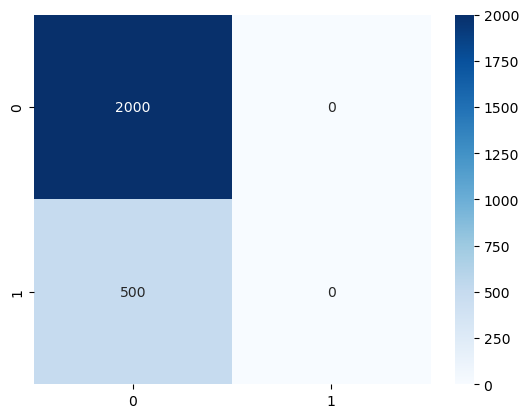

In [13]:
forest = RandomForestClassifier(class_weight=class_weights, random_state=42)
forest.fit(X_train, y_train)
y_proba = forest.predict_proba(X_test)[:, 1]
y_pred_forest = (y_proba > threshold).astype(int)

print(classification_report(y_test, y_pred_forest))
sns.heatmap(confusion_matrix(y_test, y_pred_forest), annot=True, fmt='d', cmap='Blues')

In [14]:
print(f'recall {recall_score(y_test, y_pred_forest)}')
print(f'precision {precision_score(y_test, y_pred_forest)}')
print(f'f1 {f1_score(y_test, y_pred_forest)}')

recall 0.0
precision 0.0
f1 0.0


In [15]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gs_forest = GridSearchCV(estimator=RandomForestClassifier(class_weight=class_weights, random_state=42), 
                         param_grid=param_grid, cv=skf,
                         scoring='recall')

gs_forest.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

              precision    recall  f1-score   support

           0       0.79      0.41      0.54      2000
           1       0.19      0.57      0.29       500

    accuracy                           0.44      2500
   macro avg       0.49      0.49      0.41      2500
weighted avg       0.67      0.44      0.49      2500



<Axes: >

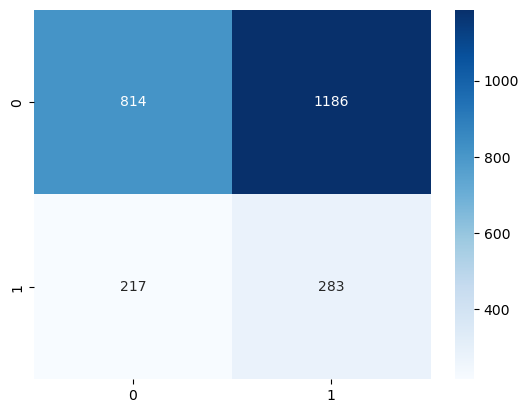

In [16]:
y_proba_grid = gs_forest.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_grid_forest = (y_proba_grid > threshold).astype(int)

print(classification_report(y_test, y_pred_grid_forest))
sns.heatmap(confusion_matrix(y_test, y_pred_grid_forest), annot=True, fmt='d', cmap='Blues')

In [17]:
print(f'recall {recall_score(y_test, y_pred_grid_forest)}')
print(f'precision {precision_score(y_test, y_pred_grid_forest)}')
print(f'f1 {f1_score(y_test, y_pred_grid_forest)}')

recall 0.566
precision 0.19264805990469708
f1 0.28745556119857796


xgboost

In [18]:
negatives = sum(y_train == 0)
positives = sum(y_train == 1)
scale_pos_weight = negatives / positives

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1 
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      2000
           1       0.18      0.16      0.17       500

    accuracy                           0.69      2500
   macro avg       0.49      0.49      0.49      2500
weighted avg       0.67      0.69      0.68      2500



<Axes: >

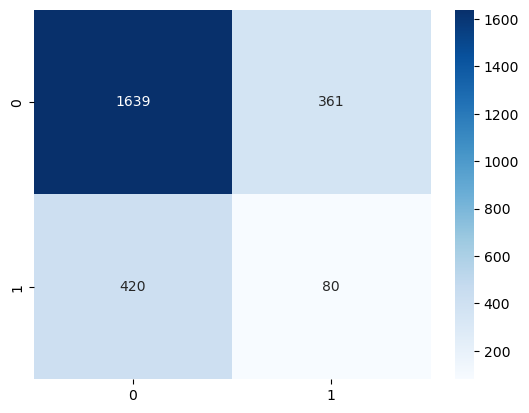

In [19]:
y_proba = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba > threshold).astype(int)

print(classification_report(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')

In [20]:
print(f'recall {recall_score(y_test, y_pred_xgb)}')
print(f'precision {precision_score(y_test, y_pred_xgb)}')
print(f'f1 {f1_score(y_test, y_pred_xgb)}')

recall 0.16
precision 0.18140589569160998
f1 0.17003188097768332


In [21]:
param_grid = {
    'max_depth': randint(3, 7),
    'learning_rate': uniform(0.03, 0.15),
    'n_estimators': randint(150, 350), 
    'subsample': uniform(0.7, 0.25),
    'colsample_bytree': uniform(0.7, 0.25),
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 1.5, scale_pos_weight * 2],
    'min_child_weight': randint(1, 5)
}

rs_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

rs_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....002312A6572C0>, 'learning_rate': <scipy.stats....002312A624D70>, 'max_depth': <scipy.stats....002312A4ED4C0>, 'min_child_weight': <scipy.stats....002312B743800>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User 

              precision    recall  f1-score   support

           0       0.85      0.02      0.04      2000
           1       0.20      0.98      0.33       500

    accuracy                           0.21      2500
   macro avg       0.53      0.50      0.19      2500
weighted avg       0.72      0.21      0.10      2500



<Axes: >

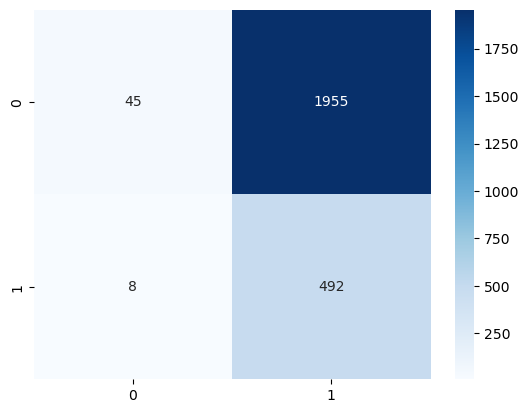

In [22]:
y_proba_grid = rs_xgb.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_grid_xgb = (y_proba_grid > threshold).astype(int)

print(classification_report(y_test, y_pred_grid_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_grid_xgb), annot=True, fmt='d', cmap='Blues')

In [23]:
print(f'recall {recall_score(y_test, y_pred_grid_xgb)}')
print(f'precision {precision_score(y_test, y_pred_grid_xgb)}')
print(f'f1 {f1_score(y_test, y_pred_grid_xgb)}')

recall 0.984
precision 0.20106252554147935
f1 0.33389888021717


In [24]:
results_df = pd.DataFrame({
    'Model': ['LogReg_Base', 'LogReg_GS', 'Forest_Base', 'Forest_GS', 'XGB_Base', 'XGB_RS'],
    'Precision': [precision_score(y_test, y_pred_log),
                  precision_score(y_test, y_pred_grid_log),
                  precision_score(y_test, y_pred_forest),
                  precision_score(y_test,  y_pred_grid_forest),
                  precision_score(y_test, y_pred_xgb),
                  precision_score(y_test, y_pred_grid_xgb)],
    'Recall': [recall_score(y_test, y_pred_log),
               recall_score(y_test, y_pred_grid_log),
               recall_score(y_test, y_pred_forest),
               recall_score(y_test,  y_pred_grid_forest),
               recall_score(y_test, y_pred_xgb),
               recall_score(y_test, y_pred_grid_xgb)],
    'F1': [f1_score(y_test, y_pred_log),
           f1_score(y_test, y_pred_grid_log),
           f1_score(y_test, y_pred_forest),
           f1_score(y_test, y_pred_grid_forest),
           f1_score(y_test, y_pred_xgb),
           f1_score(y_test, y_pred_grid_xgb)]
})

results_df = results_df.round(4)
results_df = results_df.sort_values('Recall', ascending=False).reset_index(drop=True)
results_df


,Model,Precision,Recall,F1
0,XGB_RS,0.2011,0.984,0.3339
1,LogReg_GS,0.2016,0.796,0.3217
2,LogReg_Base,0.2004,0.666,0.3080
3,Forest_GS,0.1926,0.566,0.2875
4,XGB_Base,0.1814,0.160,0.1700
5,Forest_Base,0.0000,0.000,0.0000


Вывод: из таблицы видно, что с подбором гипераметров recall не стал лучше. Из всех моделей лучший F1-score показал XGBoost с подбором гиперпараметров, благодаря высокому recall. Logistic Regression с подбором гиперпараметров также показала неплохой баланс Precision/Recall. Модели показали слабые результаты из-за дисбаланса классов и малого объёма данных.